# Inference and Autoregressive Generation

> During training, the model sees the correct preceding context (Teacher Forcing), so all positions can be computed in parallel. During inference, there is no correct answer -- the model must first generate one token, append it to the input, then generate the next.
>
> This section implements the core strategies of autoregressive generation: greedy decoding, temperature sampling, top-k/top-p truncation, and beam search. We first train a small model so that the effect of each strategy is directly visible in the output.

Autoregressive Generation is the fundamental way all current LLMs produce text. The model generates the first token, appends it to the input, generates the second, appends it back, and so on in a loop.

Only one token is generated at a time, but the entire accumulated sequence must go through Attention computation again each step. This serial nature is the root cause of slow LLM inference, and it is also the key reason the model can dynamically adjust its output based on what has already been generated.

## 1. The Fundamental Difference Between Inference and Training

```
Training:  Has answer -> All positions compute loss in parallel -> Teacher Forcing
Inference: No answer  -> Must generate tokens one by one      -> Autoregressive
```

Autoregressive means: use the model's own output as the input for the next step.

```
Step 1: Input [BOS]              -> Model predicts -> I
Step 2: Input [BOS, I]           -> Model predicts -> love
Step 3: Input [BOS, I, love]     -> Model predicts -> you
Step 4: Input [BOS, I, love, you] -> Model predicts -> EOS -> Stop
```

Like a snake eating its own tail -- it keeps getting longer.

## 2. Training a Model That Shows Visible Effects

To make the effects of temperature, top-k, and other strategies clearly visible, we need a model whose output is not completely deterministic (there is probability spread) but also not completely random. We use training data with patterns that are regular but not unique: given a few tokens, there are multiple reasonable continuations.

Here we use a "multi-path pattern": each position has 2-3 reasonable successors, and the model assigns different probabilities to different successors. This way, the effect of temperature can be directly observed in the output.

In [1]:
import torch
import torch.nn as nn

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
                dim_feedforward=4*d_model, batch_first=True, activation='relu')
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch, seq = x.shape
        pos = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        h = self.token_emb(x) + self.pos_emb(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            h = block(h, src_mask=mask, is_causal=True)
        return self.lm_head(h)

VOCAB = 16

def make_multi_path_data(n=800, seq_len=10):
    # Multiple paths: starting from token 1, there are two possible paths
    # Path A: 1->2->3->4->5->6->7->8->1...  (70%)
    # Path B: 1->2->9->10->11->12->7->8->1... (30%)
    # Branch point at position 2: token 3 or 9
    data = []
    for i in range(n):
        path = i % 10  # about 70% take path A
        seq = [1, 2]
        if path < 7:
            seq.extend([3, 4, 5, 6])
        else:
            seq.extend([9, 10, 11, 12])
        seq.extend([7, 8])
        data.append(seq[:seq_len])
    return torch.tensor(data)

train_data = make_multi_path_data()
print(f'Training data: {train_data.shape}')
print(f'Path A sample: {train_data[0].tolist()}')
print(f'Path B sample: {train_data[7].tolist()}')
print(f'Branch point: position 2 -> token 3 (70%) or token 9 (30%)')


trainingdata: torch.Size([800, 8])Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads,
                dim_feedforward=4*d_model, batch_first=True, activation='relu')
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        batch, seq = x.shape
        pos = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        h = self.token_emb(x) + self.pos_emb(pos)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            h = block(h, src_mask=mask, is_causal=True)
        return self.lm_head(h)

VOCAB = 16

def make_multi_path_data(n=800, seq_len=10):
    # Multiple paths: starting from token 1, there are two possible paths
    # Path A: 1->2->3->4->5->6->7->8->1...  (70%)
    # Path B: 1->2->9->10->11->12->7->8->1... (30%)
    # Branch point at position 2: token 3 or 9
    data = []
    for i in range(n):
        path = i % 10  # about 70% take path A
        seq = [1, 2]
        if path < 7:
            seq.extend([3, 4, 5, 6])
        else:
            seq.extend([9, 10, 11, 12])
        seq.extend([7, 8])
        data.append(seq[:seq_len])
    return torch.tensor(data)

train_data = make_multi_path_data()
print(f'Training data: {train_data.shape}')
print(f'Path A sample: {train_data[0].tolist()}')
print(f'Path B sample: {train_data[7].tolist()}')
print(f'Branch point: position 2 -> token 3 (70%) or token 9 (30%)')


trainingdata: torch.Size([800, 8])Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
model = SimpleGPT(VOCAB)

# Training target: given first 9 tokens, predict the next at each position
# Input train_data[:, :-1], target train_data[:, 1:] (shifted by one)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

print('Training started...')
for epoch in range(100):
    inputs = train_data[:, :-1]
    targets = train_data[:, 1:]
    logits = model(inputs)
    loss = loss_fn(logits.reshape(-1, VOCAB), targets.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f'  epoch {epoch+1:3d}, loss = {loss.item():.4f}')

print(f'\nTraining complete, final loss = {loss.item():.4f}')


Read the values printed above and connect them to the concept in this cell.  epoch  20, loss = 0.7551
  epoch  40, loss = 0.3908
  epoch  60, loss = 0.2707
  epoch  80, loss = 0.2104
  epoch 100, loss = 0.1764

Loss

In [4]:
# Check the model's probability distribution at the branch point
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    # Input [1, 2], check prediction at position 2
    logits = model(torch.tensor([[1, 2]]))
    probs = F.softmax(logits[0, -1, :], dim=-1)

print('After input [1, 2], model probability distribution for next token:')
for tok_id in range(VOCAB):
    p = probs[tok_id].item()
    if p > 0.01:
        bar = '#' * int(p * 50)
        print(f'  token {tok_id:2d}: {p:.3f} {bar}')

print(f'\ntoken 3 (Path A): {probs[3].item():.1%}')
print(f'token 9 (Path B): {probs[9].item():.1%}')
print(f'\nThe model learned the probability distribution of both paths! Temperature adjustment will change which path to take.')


Read the values printed above and connect them to the concept in this cell.  token  3: 0.657 ████████████████████████████████
  token  7: 0.011 
  token  9: 0.267 █████████████

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

## 3. Greedy Decoding

At each step, select the token with the highest probability. The advantage is determinism and speed -- the same input always produces the same output. The disadvantage is that once a token is chosen, the opportunity to explore other branches is permanently lost.

In [5]:
import torch

def generate_greedy(model, input_ids, max_new_tokens=20, eos_id=None):
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(generated)
            next_logits = logits[0, -1, :]
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            if eos_id is not None and next_token.item() == eos_id:
                break
    return generated

prompt = torch.tensor([[1, 2]])
result = generate_greedy(model, prompt, max_new_tokens=12)
print(f'Greedy result: {result[0].tolist()}')
print(f'\nGreedy always picks the highest probability, so it always takes Path A (token 3).')
print(f'Even though Path B has 30% probability, Greedy will never choose it.')


Greedy Result: [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8, 7, 10]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 4. Temperature: Controlling Randomness

Temperature controls the shape of the probability distribution by scaling logits:

```
probability = softmax(logits / temperature)

temperature = 0.1 -> very peaked distribution -> almost greedy
temperature = 1.0 -> original distribution
temperature = 2.0 -> flatter distribution  -> more random
```

In [6]:
# Effect of temperature on the branch point
import torch
import torch.nn.functional as F

model.eval()
with torch.no_grad():
    logits = model(torch.tensor([[1, 2]]))[0, -1, :]

print('=== Effect of Temperature on Branch Point Probabilities ===')
print(f'{"Temperature":>12}  {"P(token 3)":>10}  {"P(token 9)":>10}  {"Ratio 3/9":>8}')
print('-' * 48)
for T in [0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 5.0]:
    probs = F.softmax(logits / T, dim=-1)
    p3 = probs[3].item()
    p9 = probs[9].item()
    ratio = p3 / p9 if p9 > 0 else float('inf')
    print(f'{T:>12.1f}  {p3:>10.3f}  {p9:>10.3f}  {ratio:>8.1f}')

print(f'\nLow temperature: token 3 is almost 100%, equivalent to greedy')
print(f'High temperature: the gap between token 3 and 9 shrinks, model more likely to explore Path B')


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.------------------------------------------------
         0.1       1.000       0.000    8060.7
         0.3       0.952       0.048      20.1
         0.5       0.857       0.142       6.0
         1.0       0.657       0.267       2.5
         1.5       0.476       0.261       1.8
         2.0       0.349       0.223       1.6
         5.0       0.141       0.118       1.2

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

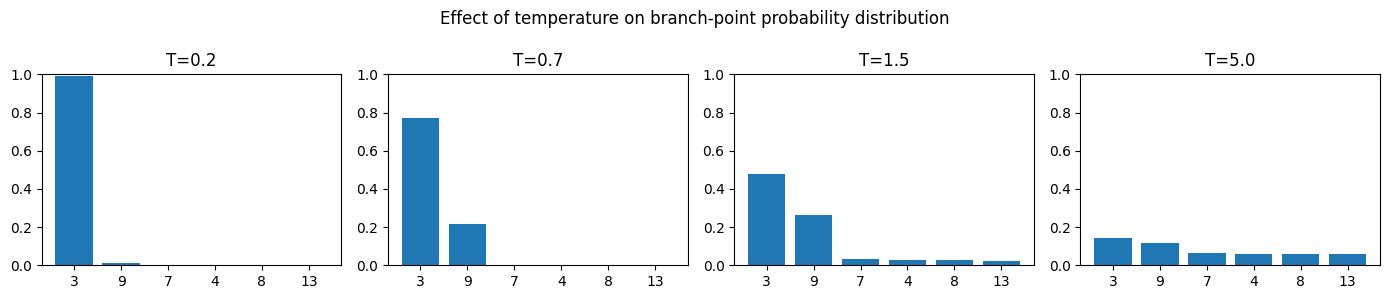

In [7]:
# Visualization
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
example_logits = logits.clone()
for ax, T in zip(axes, [0.2, 0.7, 1.5, 5.0]):
    probs = F.softmax(example_logits / T, dim=-1)
    top_k_probs, top_k_idx = torch.topk(probs, 6)
    ax.bar(range(6), top_k_probs.numpy())
    ax.set_xticks(range(6))
    ax.set_xticklabels([str(i.item()) for i in top_k_idx])
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)
plt.suptitle('Effect of Temperature on Branch Point Probability Distribution')
plt.tight_layout()
plt.show()


In [8]:
# Actual generation results with different temperatures
import torch
import torch.nn.functional as F

print('Same prompt [1, 2], generation results with different temperatures:')
print()

for T in [0.1, 0.5, 1.0, 1.5, 2.0]:
    results = []
    for seed in range(5):
        torch.manual_seed(seed)
        generated = torch.tensor([[1, 2]])
        model.eval()
        with torch.no_grad():
            for _ in range(12):
                logits = model(generated)[0, -1, :] / T
                probs = F.softmax(logits, dim=-1)
                token = torch.multinomial(probs, 1).unsqueeze(0)
                generated = torch.cat([generated, token], dim=1)
        results.append(generated[0, 2:6].tolist())  # Check branch point choice
    paths = ['A' if r[0] == 3 else 'B' for r in results]
    print(f'T={T:.1f}: {results}  Path: {paths}')

print(f'\nLow temperature: almost all take Path A')
print(f'High temperature: Path B starts appearing, diversity increases')


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 5. Sampling Truncation: Top-k and Top-p

Section 4 showed that temperature can only change the sharpness of the probability distribution -- it cannot push any token's probability to exactly zero. Even at very low temperatures, those nearly-impossible tokens in the vocabulary -- numbers never seen during training, symbols completely unrelated to the context -- still retain non-zero probability.

When temperature is high, the problem becomes more pronounced: as the distribution gets flattened, a large number of tail tokens have their probabilities lifted up. Sampling directly from the full vocabulary via multinomial (this approach is called Pure Sampling) makes it easy to draw words that should never appear. Below we first observe this problem on SimpleGPT, then introduce two truncation schemes in turn: Top-k and Top-p.

In [9]:
import torch
import torch.nn.functional as F

# Pure Sampling: sample directly from the full-vocabulary softmax, no truncation
def pure_sampling(model, input_ids, max_new=6, temperature=1.0, seed=0):
    torch.manual_seed(seed)
    generated = input_ids.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

# First look at the probability distribution of the next token after [1, 2]
model.eval()
with torch.no_grad():
    probs_at_branch = F.softmax(model(torch.tensor([[1, 2]]))[0, -1, :], dim=-1)

print('After input [1, 2], probability of each next token (vocab=16):')
for tid in range(VOCAB):
    p = probs_at_branch[tid].item()
    flag = ' <- main candidate' if p > 0.1 else ''
    print(f'  token {tid:2d}: {p:.4f}{flag}')

low_prob_count = (probs_at_branch < 0.01).sum().item()
print(f'\nNumber of tokens with probability below 1%: {low_prob_count} / {VOCAB}')
print('These "almost impossible" tokens can still be drawn under Pure Sampling')

# Run Pure Sampling 10 times on the same prompt, deliberately flatten the distribution
print('\n=== Pure Sampling run 10 times (temperature=1.5, distribution flattened) ===')
valid_path_tokens = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
for seed in range(10):
    r = pure_sampling(model, torch.tensor([[1, 2]]), max_new=6, temperature=1.5, seed=seed)
    seq = r[0].tolist()
    has_garbage = any(t not in valid_path_tokens for t in seq[2:])
    flag = ' ! off-path token appeared' if has_garbage else ''
    print(f'  seed={seed}: {seq}{flag}')


Read the values printed above and connect them to the concept in this cell.  token  0: 0.0026
  token  1: 0.0029
  token  2: 0.0062
Read the values printed above and connect them to the concept in this cell.  token  4: 0.0099
  token  5: 0.0055
  token  6: 0.0023
  token  7: 0.0106
  token  8: 0.0095
Read the values printed above and connect them to the concept in this cell.  token 10: 0.0051
  token 11: 0.0021
  token 12: 0.0046
  token 13: 0.0077
  token 14: 0.0038
  token 15: 0.0030

Number of tokens: Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  seed=2: [1, 2, 3, 11, 9, 6, 7, 4]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  s

### 5.1 Top-k: Fixed Number of Candidates

The most direct truncation method is Top-k: regardless of the distribution shape, keep only the k highest-probability tokens, set all the rest to zero, then re-normalize and sample within those k.

Specifically for the current example, after input [1, 2] take k=2. From the probability table above, pick the top two: token 3 and token 9. The other 14 tokens are all set to zero; after re-normalizing, the probabilities of the remaining two barely change:

```
P(token 3 | top-2) = 0.66 / (0.66 + 0.27) = 0.71
P(token 9 | top-2) = 0.27 / (0.66 + 0.27) = 0.29
```

k=2 for this prompt is equivalent to "only choosing between the two paths" -- clean candidates, never producing irrelevant tokens. Note that k=1 is a special case: it keeps only the single highest-probability token, which degenerates into Greedy.

In [10]:
import torch
import torch.nn.functional as F

def top_k_filter(logits, k):
    """Top-k truncation: keep the k highest-probability tokens, set the rest to -inf (i.e. 0 after softmax)"""
    if k >= logits.size(-1):
        return logits
    # Take the k-th largest value as threshold; mask anything below it
    kth_val = torch.topk(logits, k).values[-1]
    filtered = logits.clone()
    filtered[filtered < kth_val] = float('-inf')
    return filtered

# Hand-check: k=2, input [1, 2]
model.eval()
with torch.no_grad():
    logits_at_branch = model(torch.tensor([[1, 2]]))[0, -1, :]

filtered = top_k_filter(logits_at_branch.clone(), k=2)
probs_after = F.softmax(filtered, dim=-1)
print('Probability distribution after Top-k=2 filtering:')
for tid in range(VOCAB):
    p = probs_after[tid].item()
    if p > 0:
        print(f'  token {tid:2d}: {p:.4f}')
print('\nKey observation: only 2 of the 16 tokens retain probability, the other 14 are pressed to 0')

# Effect of different k values at the branch point
print('\n=== Same prompt [1, 2], different k values (temperature=1.0, 8 seeds) ===')
def sample_with_filter(model, input_ids, max_new=4, temperature=1.0,
                      top_k=None, top_p=None, seed=0):
    torch.manual_seed(seed)
    generated = input_ids.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / temperature
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

for k in [1, 2, 4, 8, None]:
    picks = [sample_with_filter(model, torch.tensor([[1, 2]]),
             max_new=4, top_k=k, seed=s)[0, 2].item() for s in range(8)]
    label = f'k={k}' if k else 'no filter'
    paths = ['A' if t == 3 else ('B' if t == 9 else f'?{t}') for t in picks]
    print(f'  {label:>9s}: 3rd-position token = {picks}  Path {paths}')

print('\nk=1 -> degenerates into greedy (always takes A)')
print('k=2 -> candidates are only the two paths, clean')
print('k>=4 / no filter -> too many candidates, off-path tokens start appearing (? marker)')


Read the values printed above and connect them to the concept in this cell.  token  3: 0.7108
  token  9: 0.2892

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### 5.2 Top-p: Adaptive Truncation by Cumulative Probability

The problem with Top-k is that k is hardcoded. Our vocabulary is only 16, so k=2 happens to correspond to the two paths; but real large-model vocabularies routinely have 50,000 or 100,000 tokens, and the same k means completely different things across different contexts:

- When the distribution is highly concentrated (e.g. after "1+1=", "2" is almost 100%), k=40 pulls in 39 tokens that should never appear as candidates
- When the distribution is highly uniform (e.g. an open-ended question like "what do you think..."), k=40 may not be enough to cover all reasonable candidates

A more sensible approach is to truncate by "cumulative probability": sort tokens by probability from high to low, accumulate in turn, and stop once the cumulative value reaches the threshold p. The set of tokens included in the accumulation is the so-called "nucleus", hence the name Nucleus Sampling.

Under the distribution of the current prompt [1, 2], with p=0.9, accumulating up to P(3) ~ 0.66 is still not enough; adding P(9) ~ 0.27 gives a cumulative 0.92, exceeding 0.9, so the final retained tokens are token 3 and 9 -- the same result as Top-k=2. The difference shows up in more complex real-world distributions.

In [11]:
import torch
import torch.nn.functional as F

def top_p_filter(logits, p):
    """Top-p truncation: keep all tokens before the cumulative probability reaches p, set the rest to -inf"""
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cum_probs = torch.cumsum(sorted_probs, dim=-1)
    # Mark positions where cumulative probability exceeds p for removal
    remove = cum_probs > p
    # Shift right by one: also keep the token whose cumulative probability just exceeded p (HuggingFace style)
    remove[1:] = remove[:-1].clone()
    remove[0] = False
    # Write -inf in sorted coordinates, then scatter back to original order
    sorted_logits[remove] = float('-inf')
    out = torch.full_like(logits, float('-inf'))
    out[sorted_idx] = sorted_logits
    return out

# Hand-check: how many tokens different p values retain at the branch point
print('=== Input [1, 2], candidates retained for different p ===')
for p in [0.5, 0.7, 0.9, 0.99]:
    filtered = top_p_filter(logits_at_branch.clone(), p=p)
    probs = F.softmax(filtered, dim=-1)
    kept = [tid for tid in range(VOCAB) if probs[tid].item() > 0]
    print(f'  p={p}: retain {len(kept)} tokens {kept}')

print('\np=0.5: P(token 3)~=0.66 already exceeds 0.5, but remove[0]=False guarantees at least 1 token')
print('p=0.9: P(3)+P(9)~=0.92 exceeds 0.9, retain 2 tokens; same result as Top-k=2 here')

# Same prompt run multiple times, see the effect of different Top-p values
print('\n=== Same prompt [1, 2], different p values (temperature=1.5) ===')
for p in [0.5, 0.9, 0.99, None]:
    picks = []
    for s in range(8):
        torch.manual_seed(s)
        generated = torch.tensor([[1, 2]])
        model.eval()
        with torch.no_grad():
            logits = model(generated)[0, -1, :] / 1.5
            if p is not None:
                logits = top_p_filter(logits, p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1)
            picks.append(token.item())
    label = f'p={p}' if p else 'no filter'
    paths = ['A' if t == 3 else ('B' if t == 9 else f'?{t}') for t in picks]
    print(f'  {label:>9s}: next token = {picks}  Path {paths}')


Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

### 5.3 Industrial Default: Top-k and Top-p Together

Top-p solves Top-k's "fixed count" problem, but it has its own edge case: when the model has no idea what to say next and the distribution is very uniform, the cumulative probability of the top few tokens grows very slowly, and Top-p will include a large number of low-probability tokens as candidates -- back to the Pure Sampling problem.

The common industry compromise is to set two upper bounds simultaneously: first truncate by Top-k (to prevent candidate explosion, e.g. k=40), then apply Top-p within the k candidates (to adapt to the probability distribution, e.g. p=0.9), and finally normalize and sample. This way the candidate count never exceeds k, while in most cases it adapts by p. HuggingFace transformers' `model.generate(do_sample=True, top_k=40, top_p=0.9)` follows exactly this path.

In [12]:
import torch
import torch.nn.functional as F

def generate_sampled(model, input_ids, max_new=10, temperature=1.0,
                    top_k=None, top_p=None, seed=42):
    """General sampling generation: optional temperature / top-k / top-p (reuses the filters defined in Section 5)"""
    torch.manual_seed(seed)
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :] / max(temperature, 0.01)
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    return generated

# Same prompt [1, 2], high temperature flattens distribution, compare strategies
prompt = torch.tensor([[1, 2]])
print('Same prompt [1, 2], temperature=1.5, comparison of truncation strategies:')
print()
configs = [
    ('Pure Sampling',          dict()),
    ('Top-k=2',                dict(top_k=2)),
    ('Top-p=0.9',              dict(top_p=0.9)),
    ('Top-k=2 + Top-p=0.9',    dict(top_k=2, top_p=0.9)),
]
for name, cfg in configs:
    r = generate_sampled(model, prompt, max_new=10, temperature=1.5, seed=42, **cfg)
    print(f'  {name:>22s}: {r[0].tolist()}')

print('\nKey observations:')
print('  Pure Sampling at high temperature introduces many off-path tokens')
print('  Top-k or Top-p alone is enough to constrain candidates back to a reasonable range')
print('  The combination is equivalent to "taking the intersection", the most robust')


Read the values printed above and connect them to the concept in this cell.
           Pure Sampling: [1, 2, 3, 4, 5, 12, 11, 8, 2, 0, 1, 6]
                 Top-k=2: [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8]
               Top-p=0.9: [1, 2, 3, 4, 5, 12, 9, 8, 2, 7, 12, 6]
     Top-k=2 + Top-p=0.9: [1, 2, 3, 4, 5, 6, 7, 8, 4, 2, 7, 8]

Key observation:Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## 6. Beam Search

Greedy picks the best at each step, but local optimum does not equal global optimum. Beam Search maintains K paths simultaneously and selects the K highest-scoring paths from all candidates at each step.

Suitable for: translation, summarization, and other tasks with "clear answers". Not suitable for: creative writing -- beam search makes the output boring.

In [13]:
import torch
import torch.nn.functional as F

def beam_search(model, input_ids, beam_size=3, max_new=12):
    beams = [(0.0, input_ids.clone())]
    for _ in range(max_new):
        candidates = []
        for score, seq in beams:
            with torch.no_grad():
                logits = model(seq)[0, -1, :]
            log_probs = F.log_softmax(logits, dim=-1)
            top_probs, top_idx = torch.topk(log_probs, beam_size)
            for i in range(beam_size):
                new_seq = torch.cat([seq, top_idx[i].unsqueeze(0).unsqueeze(0)], dim=1)
                candidates.append((score + top_probs[i].item(), new_seq))
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_size]
    best_score, best_seq = beams[0]
    return best_seq, best_score

prompt = torch.tensor([[1, 2]])
print('=== Beam Search ===')
for bs in [1, 2, 3, 5]:
    result, score = beam_search(model, prompt, beam_size=bs, max_new=10)
    label = 'Greedy' if bs == 1 else f'Beam k={bs}'
    print(f'{label:12s}: {result[0].tolist()}  score={score:.2f}')


=== Beam Search ===
Greedy      : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98
Beam k=2    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98
Beam k=3    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98
Beam k=5    : [1, 2, 3, 4, 5, 6, 7, 8, 3, 7, 7, 8]  score=-3.98


## 7. Repetition Penalty

LLMs are prone to falling into repetitive loops during generation. Repetition Penalty reduces the logit of tokens that have already appeared, breaking the loop.

Penalty formula: if logit > 0, divide by penalty; otherwise multiply by penalty. penalty > 1 means applying the penalty.

In [14]:
import torch
import torch.nn.functional as F

def apply_repetition_penalty(logits, token_ids, penalty=1.2):
    if penalty == 1.0:
        return logits
    for tid in set(token_ids.tolist()):
        score = logits[tid]
        logits[tid] = score / penalty if score > 0 else score * penalty
    return logits

# Use a prompt that tends to repeat
# Run multiple times and measure repetition rate
print('=== Repetition Penalty Effect ===')
print(f'{"penalty":>8}  {"Generated Sequence":>40}  {"Unique Ratio":>6}')
print('-' * 60)

prompt = torch.tensor([[1, 2, 3]])
for penalty in [1.0, 1.1, 1.3, 1.5, 2.0]:
    torch.manual_seed(42)
    generated = prompt.clone()
    model.eval()
    with torch.no_grad():
        for _ in range(15):
            logits = model(generated)[0, -1, :].clone()
            logits = apply_repetition_penalty(logits, generated[0], penalty)
            probs = F.softmax(logits / 0.8, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)
    tokens = generated[0].tolist()
    unique_ratio = len(set(tokens)) / len(tokens)
    print(f'{penalty:>8.1f}  {str(tokens):>40}  {unique_ratio:>5.1%}')


=== Repetition Penalty Result ===Read the values printed above and connect them to the concept in this cell.------------------------------------------------------------
     1.0  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 7, 8, 6, 10, 11, 10, 3, 2]  55.6%
     1.1  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 7, 8, 6, 10, 11, 10, 3, 2]  55.6%
     1.3  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 0, 12, 6, 10, 11, 10, 3, 2]  66.7%
     1.5  [1, 2, 3, 4, 5, 6, 7, 8, 8, 7, 0, 12, 6, 10, 11, 10, 3, 0]  66.7%
     2.0  [1, 2, 3, 4, 5, 6, 7, 8, 8, 2, 5, 6, 6, 10, 11, 10, 3, 12]  61.1%


## 8. Chat Templates and System Prompt

The generation examples above all follow the pattern of "given some text, continue writing." In practice, LLMs are used in a conversational format. Chat templates stitch multi-turn conversations into a single piece of text that the model can understand.

Different models use different templates. Using the wrong template leads to degraded response quality. This is why HuggingFace's `tokenizer.apply_chat_template()` is useful -- it handles the formatting automatically.

In [15]:
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user', 'content': 'What is the attention mechanism?'},
    {'role': 'assistant', 'content': 'The attention mechanism is a...'},
    {'role': 'user', 'content': 'Can you give an example?'},
]

def apply_chatml(msgs):
    parts = []
    for m in msgs:
        parts.append(f'<|im_start|>{m["role"]}\n{m["content"]}<|im_end|>')
    parts.append('<|im_start|>assistant')
    return '\n'.join(parts)

def apply_llama(msgs):
    parts = []
    for m in msgs:
        if m['role'] == 'system':
            parts.append(f'<<SYS>>\n{m["content"]}<</SYS>>\n\n')
        elif m['role'] == 'user':
            parts.append(f'[INST] {m["content"]} [/INST]')
        else:
            parts.append(f' {m["content"]} </s><s>')
    return ''.join(parts)

def apply_alpaca(msgs):
    system = next((m['content'] for m in msgs if m['role'] == 'system'), '')
    text = 'Below is an instruction. Write a response.\n\n'
    if system: text += f'### System\n{system}\n\n'
    for m in msgs:
        if m['role'] == 'user': text += f'### Instruction\n{m["content"]}\n\n'
        elif m['role'] == 'assistant': text += f'### Response\n{m["content"]}\n\n'
    text += '### Response\n'
    return text

print('=== ChatML (Qwen/Yi) ===')
print(apply_chatml(messages))
print('\n=== Llama Chat ===')
print(apply_llama(messages))
print('\n=== Alpaca ===')
print(apply_alpaca(messages)[:200] + '...')


=== ChatML (Qwen/Yi) ===
<|im_start|>system
Read the values printed above and connect them to the concept in this cell.<|im_start|>user
Read the values printed above and connect them to the concept in this cell.<|im_start|>assistant
Read the values printed above and connect them to the concept in this cell.<|im_start|>user
Read the values printed above and connect them to the concept in this cell.<|im_start|>assistant

=== Llama Chat ===
<<SYS>>
Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.
=== Alpaca ===
Below is an instruction. Write a response.

### SystemRead the values printed above and connect them to the concept in this cell.
### InstructionRead the values printed above and connect them to the concept in this cell.
### ResponseRead the values printed above and connect them to the concept in this cell.
### InstructionRead the values printed above and connect them to the conce

### Tips for Writing System Prompts

A few principles:

1. **Define the role clearly**: tell the model "who you are"
2. **Set boundaries**: "what not to do" is more effective than "what to do"
3. **Specify format**: "output format is JSON" or "use markdown tables"
4. **Give examples**: one example is worth a hundred rules (few-shot)

Bad System Prompt: `You are an assistant, please help the user.`

Good System Prompt:
```
You are a Python debugging expert.
Users will give you error messages and related code.
Your task:
1. Find the root cause (summarize in one sentence)
2. Provide the fix code
3. Explain why the fix works
Reply in English. Wrap code in markdown code blocks.
```

## 9. The Complete Generation Pipeline

Connecting all concepts from Part 1 to now in one flow:

```
User inputs text
    | Tokenizer.encode()          <- Part 1 & 2
token ID sequence
    | Embedding + Position         <- Part 3
vector sequence
    | N x Transformer Block        <- Part 4
logits
    | Sampling strategy            <- This section
generate tokens one by one
    | Tokenizer.decode()           <- Part 1 & 2
output text
```

GPT-4, Claude, and Gemini are all super-scaled versions of this pipeline.

In [16]:
# Complete generation function: integrating all strategies
import torch
import torch.nn.functional as F

def generate(model, input_ids, max_new=30, temperature=1.0, top_k=None, top_p=None,
            repetition_penalty=1.0, eos_id=None, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    generated = input_ids.clone()
    with torch.no_grad():
        for _ in range(max_new):
            logits = model(generated)[0, -1, :].clone()

            # 1. Repetition penalty
            if repetition_penalty != 1.0:
                logits = apply_repetition_penalty(logits, generated[0], repetition_penalty)

            # 2. Temperature
            logits = logits / max(temperature, 0.01)

            # 3. Top-k / Top-p (reuse top_k_filter / top_p_filter defined in Section 5)
            if top_k is not None:
                logits = top_k_filter(logits, top_k)
            if top_p is not None:
                logits = top_p_filter(logits, top_p)

            # 4. Sample
            probs = F.softmax(logits, dim=-1)
            token = torch.multinomial(probs, 1).unsqueeze(0)
            generated = torch.cat([generated, token], dim=1)

            # 5. EOS check
            if eos_id is not None and token.item() == eos_id:
                break
    return generated

print('Complete generation function defined!')
print('\nCommon sampling execution order (frameworks may differ):')
print('  1. Repetition Penalty -> penalize already-seen tokens')
print('  2. Temperature -> adjust distribution shape')
print('  3. Top-k / Top-p -> truncate low probabilities')
print('  4. Sampling -> sample from final distribution')
print('  5. EOS check -> whether to stop')


Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.  4. Read the values printed above and connect them to the concept in this cell.  5. Read the values printed above and connect them to the concept in this cell.

In [17]:
# Final comparison: generation results with different configurations
import torch

prompt = torch.tensor([[1, 2]])
configs = [
    ('Greedy',        dict(temperature=0.01, top_k=1)),
    ('T=0.5',         dict(temperature=0.5)),
    ('T=1.0',         dict(temperature=1.0)),
    ('T=1.5',         dict(temperature=1.5)),
    ('T=1.0, k=2',   dict(temperature=1.0, top_k=2)),
    ('T=1.0, p=0.9', dict(temperature=1.0, top_p=0.9)),
    ('T=0.8, rep=1.3', dict(temperature=0.8, repetition_penalty=1.3)),
]

print(f'{"Config":>16}  Generation Result')
print('-' * 65)
for name, cfg in configs:
    r = generate(model, prompt, max_new=12, seed=42, **cfg)
    tokens = r[0].tolist()
    path = 'A' if 3 in tokens[2:5] else ('B' if 9 in tokens[2:5] else '?')
    print(f'{name:>16}  {tokens}  Path {path}')


Read the values printed above and connect them to the concept in this cell.-----------------------------------------------------------------
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

## Summary

- Difference between inference and training: training has answers (parallel), inference has no answers (serial)
- Greedy picks the highest probability -- deterministic but uninteresting
- Temperature controls randomness -- low temperature is deterministic, high temperature is diverse
- Pure Sampling samples directly from the full vocabulary; simple but prone to drawing irrelevant tokens
- Top-k fixes the candidate count at k; k does not adapt to the distribution, suboptimal when it is very sharp or very flat
- Top-p truncates adaptively by cumulative probability -- fewer candidates when concentrated, more when dispersed; the industrial mainstream
- Top-k + Top-p together is the industrial default: fix an upper bound first, then adapt
- Beam Search maintains multiple paths -- suitable for translation/summarization
- Repetition Penalty breaks repetitive loops
- Chat templates stitch multi-turn conversations into model-readable text
- System Prompt guides the model through role and format requirements
- Common sampling execution order: penalty -> temperature -> top-k/p -> sample -> eos; the exact order depends on the framework implementation

Next section: break down the causes of slow inference, learn acceleration techniques like KV Cache, quantization, and FlashAttention.

## Exercises

**Exercise 1: Temperature Calculation**

Given logits = [2.0, 1.0, 0.5] and temperature = 0.5, what are the scaled logits?

Hint: logits / temperature

In [18]:
import torch
import torch.nn.functional as F

logits = torch.tensor([2.0, 1.0, 0.5])
T = 0.5
scaled = logits / T
probs = F.softmax(scaled, dim=-1)
print(f'Scaled: {scaled.tolist()}')
print(f'Probabilities: {probs.tolist()}')
assert torch.allclose(scaled, torch.tensor([4.0, 2.0, 1.0]))
print('✅ Exercise 1 passed')


Read the values printed above and connect them to the concept in this cell.probability: [0.8437947034835815, 0.11419519037008286, 0.04201006516814232]Exercise passed: you have understood this step.

**Exercise 2: Top-k Filtering**

Given logits = [0.1, 2.0, 0.5, 3.0, 0.01] and top_k=2, which positions are kept?

Hint: find the positions of the 2 largest values.

In [19]:
import torch

logits = torch.tensor([0.1, 2.0, 0.5, 3.0, 0.01])
topk_vals, topk_idx = torch.topk(logits, 2)
print(f'Kept positions: {topk_idx.tolist()} (values: {topk_vals.tolist()})')
assert topk_idx.tolist() == [3, 1]
print('✅ Exercise 2 passed: position 3 (value 3.0) and position 1 (value 2.0)')


Read the values printed above and connect them to the concept in this cell.Exercise passed: you have understood this step.

**Exercise 3: Top-p (Nucleus Sampling)** Top-p sampling selects the smallest set of tokens whose cumulative probability (sorted from high to low) reaches p. Given probability distribution [0.4, 0.3, 0.15, 0.1, 0.05] and p = 0.8, accumulate from highest to lowest and find which tokens are kept. Hint: accumulate from the highest probability: 0.4 + 0.3 = 0.7 < 0.8; 0.4 + 0.3 + 0.15 = 0.85 > 0.8. Keep the first 3 tokens.

In [20]:
# Exercise 3: Top-p sampling
import torch
probs = torch.tensor([0.4, 0.3, 0.15, 0.1, 0.05])
p = 0.8

# TODO: sort by probability high to low, compute cumulative probability
sorted_probs, sorted_idx = torch.sort(probs, descending=True)
cumsum = torch.cumsum(sorted_probs, dim=0)

# Find the position where cumulative probability exceeds p
# At least keep the highest-probability token
num_kept = None  # fill in the number of kept tokens here
assert num_kept is not None, 'Please compute the number of kept tokens first'
assert num_kept == 3, f'Top-p=0.8 should keep 3 tokens, you got {num_kept}'
print(f'Original probabilities: {probs.tolist()}')
print(f'Sorted: {sorted_probs.tolist()}')
print(f'Cumulative: {[f"{x:.2f}" for x in cumsum.tolist()]}')
print(f'Top-p={p} keeps {num_kept} tokens')
print('Top-p is more flexible than Top-k: fewer when concentrated, more when dispersed.')
print(chr(10004) + ' Exercise 3 passed')


## References

- Holtzman et al., [The Curious Case of Neural Text Degeneration](https://arxiv.org/abs/1904.09751), 2020 -- Nucleus Sampling (top-p)
- Fan et al., [Hierarchical Neural Story Generation](https://arxiv.org/abs/1805.04833), 2018 -- Top-k sampling
- Keskar et al., [CTRL: A Conditional Transformer Language Model](https://arxiv.org/abs/1909.05858), 2019 -- Temperature and repetition penalty
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/)